# ML. Нелинейные модели.

Пятый чекпойнт посвящен использованию более сложных моделей и архитектур в задаче годового проекта.

Трек ML:

От вас ожидается улучшение решения путем:
1) Использования нелинейных моделей ML (деревья, леса и бустинги)
2) Работа с признаками - придумать новые признаки, удалить лишние, использовать кластеризацию для получения дополнительных признаков и так далее (feature-engineering)

В результате экспериментов с моделями и признаками необходимо составить таблицу с результатами экспериментов (отобразить модели с гиперпараметрами, результаты метрик, а также сравнить время обучения моделей).

Опишите лучшее решение и попробуйте сделать выводы, почему решение оказалось лучшим.

In [29]:
import re
import warnings 
import time

import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 
import pandas as pd

from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from scipy.sparse import hstack, csr_matrix

warnings.filterwarnings("ignore")

random_state = 42

In [30]:
df_path = 'dump_features_include_numeric.csv'
df = pd.read_csv(df_path, index_col=0)
display(df)

df_train = df[(df['dataset_id']==0) | (df['dataset_id']==1)]
df_train.dropna(subset='is_toxic', inplace=True)

df_test = df[df['dataset_id']==7]

n_test_add = 60000 
df_test = pd.concat(
    [
    df_test, 
    df[(df['dataset_id']==2) | (df['dataset_id']==3) | (df['dataset_id']==4) | (df['dataset_id']==5)].dropna(subset='is_toxic').sample(
        n=n_test_add,
        random_state=random_state)
    ]
    )

print(f'df_train shape: {df_train.shape}')
print(f'df_test shape: {df_test.shape}')

,raw_text_id,dataset_id,source_platform,is_verified,text_raw,is_toxic,toxicity_type,text_encoded_noninfrm,text_encoded_emoj_emotic,text_encoded_punct,...,is_bad_word_incl,has_pronouns,starts_with_cap,ends_with_dot,has_emotional_sym,has_repeating_letters_3plus,has_url,has_number,has_mention,has_hashtag
0,0,0,"2ch, pikabu",1,"Верблюдов-то за что? Дебилы, бл...\n",1.0,NaN,"Верблюдов-то за что? Дебилы, бл...","Верблюдов-то за что? Дебилы, бл...",Верблюдов[SPP_0]то за что[SPP_1] Дебилы[SPP_2]...,...,0,0,1,0,0,0,0,0,0,0
1,1,0,"2ch, pikabu",1,"Хохлы, это отдушина затюканого россиянина, мол...",1.0,NaN,"Хохлы, это отдушина затюканого россиянина, мол...","Хохлы, это отдушина затюканого россиянина, мол...",Хохлы[SPP_2] это отдушина затюканого россиянин...,...,0,0,1,1,0,0,0,0,0,0
2,2,0,"2ch, pikabu",1,Собаке - собачья смерть\n,1.0,NaN,Собаке - собачья смерть,Собаке - собачья смерть,Собаке [SPP_0] собачья смерть,...,0,0,1,0,0,0,0,0,0,0
3,3,0,"2ch, pikabu",1,"Страницу обнови, дебил. Это тоже не оскорблени...",1.0,NaN,"Страницу обнови, дебил. Это тоже не оскорблени...","Страницу обнови, дебил. Это тоже не оскорблени...",Страницу обнови[SPP_2] дебил[SPP_3] Это тоже н...,...,0,0,1,0,0,0,0,0,0,0
4,4,0,"2ch, pikabu",1,"тебя не убедил 6-страничный пдф в том, что Скр...",1.0,NaN,"тебя не убедил [NUM]-страничный пдф в том, что...","тебя не убедил [NUM]-страничный пдф в том, что...",тебя не убедил [NUM][SPP_0]страничный пдф в то...,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
455550,455550,7,"Social Media, TV-Scripts (South Park)",0,"Fox News сообщил о работе Трампа в выходные, н...",0.0,NaN,"Fox News сообщил о работе Трампа в выходные, н...","Fox News сообщил о работе Трампа в выходные, н...",Fox News сообщил о работе Трампа в выходные[SP...,...,0,0,1,0,0,0,0,0,0,0
455551,455551,7,"Social Media, TV-Scripts (South Park)",0,Открыто новое достижение- выжил в России https...,0.0,NaN,Открыто новое достижение- выжил в России [URL],Открыто новое достижение- выжил в России [URL],Открыто новое достижение[SPP_0] выжил в России...,...,0,0,1,0,0,0,1,0,0,0
455552,455552,7,"Social Media, TV-Scripts (South Park)",0,"Митинговал ты, а страдает Пушкин https://t.co/...",0.0,NaN,"Митинговал ты, а страдает Пушкин [URL]","Митинговал ты, а страдает Пушкин [URL]",Митинговал ты[SPP_2] а страдает Пушкин [URL],...,0,0,1,0,0,0,1,0,0,0
455553,455553,7,"Social Media, TV-Scripts (South Park)",0,"'@max_katz Полицейское государство, в котором ...",1.0,NaN,"'[MNT] Полицейское государство, в котором не д...","'[MNT] Полицейское государство, в котором не д...",[RPP_483]MNT] Полицейское государство[SPP_2] в...,...,0,0,1,0,0,0,0,0,0,0


df_train shape: (252117, 34)
df_test shape: (61455, 34)


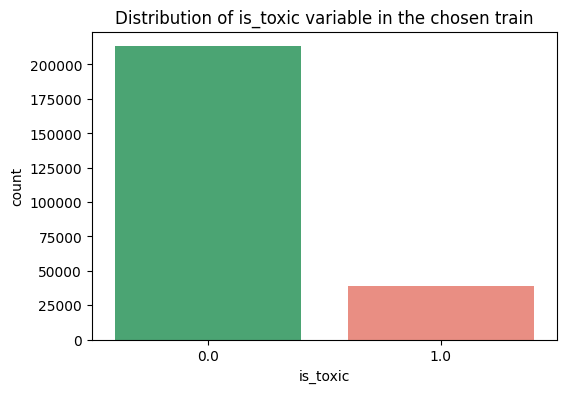

In [31]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_toxic', data=df_train.dropna(subset='is_toxic'), palette=['mediumseagreen','salmon'])
plt.title('Distribution of is_toxic variable in the chosen train')
plt.show()

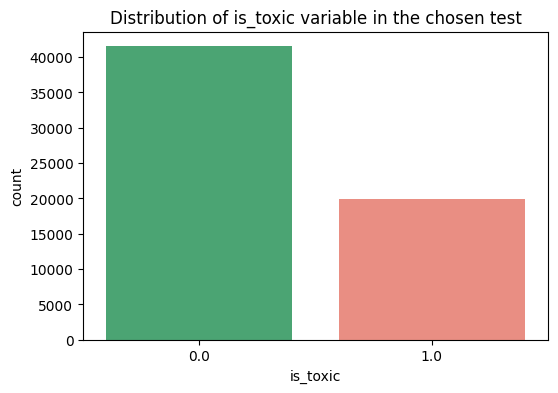

In [32]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_toxic', data=df_test, palette=['mediumseagreen','salmon'])
plt.title('Distribution of is_toxic variable in the chosen test')
plt.show()

# 1. Метрики

В качестве основной метрики выбрана `macro f1-score` (не зависит от размеров классов).

Дополнительные метрики:
- `micro f1-score`
- `weighted f1-score`
- `accuracy`
- `macro precision`
- `macro recall`
- `ROC-AUC`

In [33]:
def calculate_all_metrics(y_true, y_pred, y_pred_proba=None):
    metrics = {
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'accuracy': accuracy_score(y_true, y_pred),
        'micro_f1': f1_score(y_true, y_pred, average='micro'),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted'),
        'macro_precision': precision_score(y_true, y_pred, average='macro'),
        'macro_recall': recall_score(y_true, y_pred, average='macro'),
    }
    
    if y_pred_proba is not None:
        metrics['roc_auc'] = roc_auc_score(y_true, y_pred_proba[:, 1])
    else:
        metrics['roc_auc'] = None
    
    return metrics

def print_metrics(metrics, model_name):
    print('-' * 100)
    print(model_name)
    print(f"macro f1-score: {metrics['macro_f1']}")
    print('-' * 100)
    print(f"accuracy: {metrics['accuracy']}")
    print(f"micro f1-score: {metrics['micro_f1']}")
    print(f"weighted f1-score: {metrics['weighted_f1']}")
    print(f"macro precision: {metrics['macro_precision']}")
    print(f"macro recall: {metrics['macro_recall']}")
    if metrics['roc_auc']:
        print(f"ROC-AUC: {metrics['roc_auc']}")
    print('-' * 100)

In [34]:
target_col = 'is_toxic'

composed_features = [
    'count_spp', 'count_rpp', 'punct_after_space', 'has_emoji', 'has_emoticon',
    'has_capslock', 'is_all_lower', 'has_punctuation_spp', 'has_punctuation_rpp',
    'has_fence_ironic_style', 'count_profanity', 'has_pronouns', 'starts_with_cap',
    'has_url', 'has_number', 'has_mention', 'has_hashtag', 'ends_with_dot',
    'has_emotional_sym', 'has_repeating_letters_3plus'
]

print(f'\nДоступные числовые признаки: {composed_features}')

available_text_cols = ['text_raw', 'text_encoded_profanity', 'text_del_stop_words', 'text_without_tokens']
print(f'\nДоступные текстовые колонки: {available_text_cols}')


Доступные числовые признаки: ['count_spp', 'count_rpp', 'punct_after_space', 'has_emoji', 'has_emoticon', 'has_capslock', 'is_all_lower', 'has_punctuation_spp', 'has_punctuation_rpp', 'has_fence_ironic_style', 'count_profanity', 'has_pronouns', 'starts_with_cap', 'has_url', 'has_number', 'has_mention', 'has_hashtag', 'ends_with_dot', 'has_emotional_sym', 'has_repeating_letters_3plus']

Доступные текстовые колонки: ['text_raw', 'text_encoded_profanity', 'text_del_stop_words', 'text_without_tokens']


# 2. Применение нелинейных моделей машинного обучения

In [35]:
def run_nonlinear_experiment(configurations):
    results = []
    
    for config in tqdm(configurations, desc = 'config'):
        use_num_features = config.get('use_num', False)
        downsample = config.get('downsample', False)
        texts_col = config.get('text_col', 'text_raw')
        use_clustering = config.get('use_clustering', False)
        n_clusters = config.get('n_clusters', 10)
        
        print(f'\n{"=" * 100}')
        print(f'Config: use_num={use_num_features}, downsample={downsample}, text_col={texts_col}, clustering={use_clustering}')
        print(f'{"=" * 100}')
        
        df_train_clean = df_train.copy().dropna(subset=composed_features + [texts_col]).copy()
        df_test_clean = df_test.copy().dropna(subset=composed_features + [texts_col]).copy()
        
        if downsample:
            n_min = df_train_clean['is_toxic'].value_counts().min()
            df_train_clean = pd.concat([
                df_train_clean[df_train_clean['is_toxic'] == 0].sample(n=n_min, random_state=random_state),
                df_train_clean[df_train_clean['is_toxic'] == 1].sample(n=n_min, random_state=random_state)
            ])
        
        train_texts = df_train_clean[texts_col]
        test_texts = df_test_clean[texts_col]
        train_targets = df_train_clean[target_col]
        test_targets = df_test_clean[target_col]
        train_num_features = df_train_clean[composed_features]
        test_num_features = df_test_clean[composed_features]
        
        vectorizer = TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=3,
            max_df=0.9
        )
        X_train_tfidf = vectorizer.fit_transform(train_texts)
        X_test_tfidf = vectorizer.transform(test_texts)
        
        print(f' - tf-idf matrix size: {X_train_tfidf.shape}')
        
        if use_num_features:
            train_num_features, test_num_features = train_num_features.align(
                test_num_features, axis=1, join="left", fill_value=0
            )
            
            train_num_sparse = csr_matrix(train_num_features.values)
            test_num_sparse = csr_matrix(test_num_features.values)
            
            X_train = hstack([X_train_tfidf, train_num_sparse])
            X_test = hstack([X_test_tfidf, test_num_sparse])
            
            print(f' - train matrix size with num features: {X_train.shape}')
        else:
            X_train = X_train_tfidf
            X_test = X_test_tfidf
        
        if use_clustering:
            print(f' - добавление кластерных признаков (n_clusters={n_clusters})')
            kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
            train_clusters = kmeans.fit_predict(X_train)
            test_clusters = kmeans.predict(X_test)
            
            train_cluster_sparse = csr_matrix(train_clusters.reshape(-1, 1))
            test_cluster_sparse = csr_matrix(test_clusters.reshape(-1, 1))
            
            X_train = hstack([X_train, train_cluster_sparse])
            X_test = hstack([X_test, test_cluster_sparse])
            
            print(f' - train matrix size with clusters: {X_train.shape}')

        models = {
            'Decision Tree': DecisionTreeClassifier(random_state=random_state, max_depth=10),
            'Random Forest': RandomForestClassifier(random_state=random_state, n_estimators=100, max_depth=10, n_jobs=-1),
            'Gradient Boosting': GradientBoostingClassifier(random_state=random_state, n_estimators=100, max_depth=5),
            'XGBoost': XGBClassifier(random_state=random_state, n_estimators=100, max_depth=5, eval_metric='logloss'),
            'LightGBM': LGBMClassifier(random_state=random_state, n_estimators=100, max_depth=5, verbose=-1),
            'CatBoost': CatBoostClassifier(random_state=random_state, iterations=100, depth=5, verbose=0),
        }
        
        for name, model in models.items():
            print(f'\nобучение {name}')
            
            start_time = time.time()
            model.fit(X_train, train_targets)
            train_time = time.time() - start_time
            
            preds = model.predict(X_test)
            
            try:
                pred_proba = model.predict_proba(X_test)
            except:
                pred_proba = None
            
            metrics = calculate_all_metrics(test_targets, preds, pred_proba)
            
            record = {
                'model': name,
                'use_num_features': use_num_features, 
                'texts_col': texts_col,
                'downsampled_to_equals': downsample,
                'use_clustering': use_clustering,
                'n_clusters': n_clusters if use_clustering else None,
                'train_time_sec': train_time
            }
            record.update(metrics)
            results.append(record)
            
            print(f'время обучения: {train_time:.2f} сек')
            print_metrics(metrics, name)
        
    return results

In [36]:
results = []

In [37]:
configurations_baseline = [
    {'use_num': True, 'downsample': False, 'text_col': 'text_raw'},
]

results.extend(run_nonlinear_experiment(configurations_baseline))

config:   0%|          | 0/1 [00:00<?, ?it/s]


Config: use_num=True, downsample=False, text_col=text_raw, clustering=False
 - tf-idf matrix size: (252117, 179774)
 - train matrix size with num features: (252117, 179794)

обучение Decision Tree
время обучения: 3.11 сек
----------------------------------------------------------------------------------------------------
Decision Tree
macro f1-score: 0.8179773835426032
----------------------------------------------------------------------------------------------------
accuracy: 0.8545927914734358
micro f1-score: 0.8545927914734358
weighted f1-score: 0.8466966268781136
macro precision: 0.8681248911397059
macro recall: 0.7952262194442528
ROC-AUC: 0.8327505533599717
----------------------------------------------------------------------------------------------------

обучение Random Forest
время обучения: 0.59 сек
----------------------------------------------------------------------------------------------------
Random Forest
macro f1-score: 0.4033031691781886
---------------------------

config: 100%|██████████| 1/1 [03:38<00:00, 218.91s/it]

время обучения: 38.37 сек
----------------------------------------------------------------------------------------------------
CatBoost
macro f1-score: 0.8536639882770061
----------------------------------------------------------------------------------------------------
accuracy: 0.880091123586364
micro f1-score: 0.880091123586364
weighted f1-score: 0.8755405481733535
macro precision: 0.8889986143690362
macro recall: 0.8337785705029304
ROC-AUC: 0.8759856047056094
----------------------------------------------------------------------------------------------------


In [38]:
configurations_text = [
    {'use_num': True, 'downsample': False, 'text_col': 'text_del_stop_words'},
    {'use_num': True, 'downsample': False, 'text_col': 'text_encoded_profanity'},
    {'use_num': True, 'downsample': False, 'text_col': 'text_without_tokens'},
]

results.extend(run_nonlinear_experiment(configurations_text))

config:   0%|          | 0/3 [00:00<?, ?it/s]


Config: use_num=True, downsample=False, text_col=text_del_stop_words, clustering=False
 - tf-idf matrix size: (251635, 170144)
 - train matrix size with num features: (251635, 170164)

обучение Decision Tree
время обучения: 2.62 сек
----------------------------------------------------------------------------------------------------
Decision Tree
macro f1-score: 0.8227652749623756
----------------------------------------------------------------------------------------------------
accuracy: 0.8616352201257862
micro f1-score: 0.8616352201257862
weighted f1-score: 0.8518954196572425
macro precision: 0.8940036909859514
macro recall: 0.7952283363904338
ROC-AUC: 0.8411059308097633
----------------------------------------------------------------------------------------------------

обучение Random Forest
время обучения: 0.62 сек
----------------------------------------------------------------------------------------------------
Random Forest
macro f1-score: 0.40315663564489307
---------------

config:  33%|███▎      | 1/3 [03:04<06:09, 184.89s/it]

время обучения: 33.88 сек
----------------------------------------------------------------------------------------------------
CatBoost
macro f1-score: 0.8618681438799782
----------------------------------------------------------------------------------------------------
accuracy: 0.8872486720761235
micro f1-score: 0.8872486720761235
weighted f1-score: 0.8826487648829038
macro precision: 0.9012735573705019
macro recall: 0.840313856524404
ROC-AUC: 0.8767227785259861
----------------------------------------------------------------------------------------------------

Config: use_num=True, downsample=False, text_col=text_encoded_profanity, clustering=False
 - tf-idf matrix size: (252117, 219643)
 - train matrix size with num features: (252117, 219663)

обучение Decision Tree
время обучения: 4.85 сек
----------------------------------------------------------------------------------------------------
Decision Tree
macro f1-score: 0.8136972222569178
------------------------------------------

config:  67%|██████▋   | 2/3 [07:39<03:57, 237.95s/it]

время обучения: 43.42 сек
----------------------------------------------------------------------------------------------------
CatBoost
macro f1-score: 0.8541936833315791
----------------------------------------------------------------------------------------------------
accuracy: 0.8806281018631519
micro f1-score: 0.8806281018631519
weighted f1-score: 0.8760336227298315
macro precision: 0.8901840881418448
macro recall: 0.8340582175493566
ROC-AUC: 0.8752019906795414
----------------------------------------------------------------------------------------------------

Config: use_num=True, downsample=False, text_col=text_without_tokens, clustering=False
 - tf-idf matrix size: (250868, 98286)
 - train matrix size with num features: (250868, 98306)

обучение Decision Tree
время обучения: 1.47 сек
----------------------------------------------------------------------------------------------------
Decision Tree
macro f1-score: 0.8153647583726652
----------------------------------------------

config: 100%|██████████| 3/3 [09:26<00:00, 188.97s/it]

время обучения: 22.77 сек
----------------------------------------------------------------------------------------------------
CatBoost
macro f1-score: 0.8441967136237085
----------------------------------------------------------------------------------------------------
accuracy: 0.874687339528566
micro f1-score: 0.874687339528566
weighted f1-score: 0.8688429032967467
macro precision: 0.8883641417004657
macro recall: 0.821547886146988
ROC-AUC: 0.8727631815851087
----------------------------------------------------------------------------------------------------


In [39]:
configurations_clustering = [
    {'use_num': True, 'downsample': False, 'text_col': 'text_del_stop_words', 'use_clustering': True, 'n_clusters': 10},
    {'use_num': True, 'downsample': False, 'text_col': 'text_del_stop_words', 'use_clustering': True, 'n_clusters': 20},
]

results.extend(run_nonlinear_experiment(configurations_clustering))

config:   0%|          | 0/2 [00:00<?, ?it/s]


Config: use_num=True, downsample=False, text_col=text_del_stop_words, clustering=True
 - tf-idf matrix size: (251635, 170144)
 - train matrix size with num features: (251635, 170164)
 - добавление кластерных признаков (n_clusters=10)
 - train matrix size with clusters: (251635, 170165)

обучение Decision Tree
время обучения: 2.79 сек
----------------------------------------------------------------------------------------------------
Decision Tree
macro f1-score: 0.8224730839413528
----------------------------------------------------------------------------------------------------
accuracy: 0.8614071105028188
micro f1-score: 0.8614071105028188
weighted f1-score: 0.8516512528973746
macro precision: 0.8936564964119034
macro recall: 0.7949681822882133
ROC-AUC: 0.840696518939638
----------------------------------------------------------------------------------------------------

обучение Random Forest
время обучения: 0.65 сек
----------------------------------------------------------------

config:  50%|█████     | 1/2 [03:14<03:14, 194.65s/it]

время обучения: 35.08 сек
----------------------------------------------------------------------------------------------------
CatBoost
macro f1-score: 0.8617910587299553
----------------------------------------------------------------------------------------------------
accuracy: 0.8872649656206211
micro f1-score: 0.8872649656206211
weighted f1-score: 0.8826156803256493
macro precision: 0.9017120522494384
macro recall: 0.8400650473544375
ROC-AUC: 0.8748501537913203
----------------------------------------------------------------------------------------------------

Config: use_num=True, downsample=False, text_col=text_del_stop_words, clustering=True
 - tf-idf matrix size: (251635, 170144)
 - train matrix size with num features: (251635, 170164)
 - добавление кластерных признаков (n_clusters=20)
 - train matrix size with clusters: (251635, 170165)

обучение Decision Tree
время обучения: 2.74 сек
-------------------------------------------------------------------------------------------

config: 100%|██████████| 2/2 [06:49<00:00, 204.83s/it]

время обучения: 35.42 сек
----------------------------------------------------------------------------------------------------
CatBoost
macro f1-score: 0.8617910587299553
----------------------------------------------------------------------------------------------------
accuracy: 0.8872649656206211
micro f1-score: 0.8872649656206211
weighted f1-score: 0.8826156803256493
macro precision: 0.9017120522494384
macro recall: 0.8400650473544375
ROC-AUC: 0.8748501537913203
----------------------------------------------------------------------------------------------------


In [40]:
results_df = pd.DataFrame(results).sort_values(by='macro_f1', ascending=False)

print('Результаты:')

top_results = results_df.head(20)
display_cols = ['model', 'macro_f1', 'accuracy', 'micro_f1', 'use_num_features', 'texts_col', 'downsampled_to_equals']
print(top_results[display_cols])

print('-' * 100)
best_result = results_df.iloc[0]

print(f'Лучший результат - {best_result["model"]}')
print(f'\nmacro f1-score: {best_result["macro_f1"]}')
print(f'accuracy: {best_result["accuracy"]}')
print(f'macro_precision: {best_result["macro_precision"]}')
print(f'macro_recall: {best_result["macro_recall"]}')
print(f'use_num_features: {best_result["use_num_features"]}')
print(f'texts_col: {best_result["texts_col"]}')
print(f'downsampled_to_equals: {best_result["downsampled_to_equals"]}')

Результаты:
                model  macro_f1  accuracy  micro_f1  use_num_features  \
11           CatBoost  0.861868  0.887249  0.887249              True   
35           CatBoost  0.861791  0.887265  0.887265              True   
29           CatBoost  0.861791  0.887265  0.887265              True   
27            XGBoost  0.857082  0.884071  0.884071              True   
33            XGBoost  0.856801  0.883843  0.883843              True   
9             XGBoost  0.855265  0.882784  0.882784              True   
17           CatBoost  0.854194  0.880628  0.880628              True   
5            CatBoost  0.853664  0.880091  0.880091              True   
8   Gradient Boosting  0.849798  0.879526  0.879526              True   
32  Gradient Boosting  0.847694  0.878059  0.878059              True   
26  Gradient Boosting  0.847497  0.877912  0.877912              True   
34           LightGBM  0.846621  0.877375  0.877375              True   
21            XGBoost  0.845979  0.8763

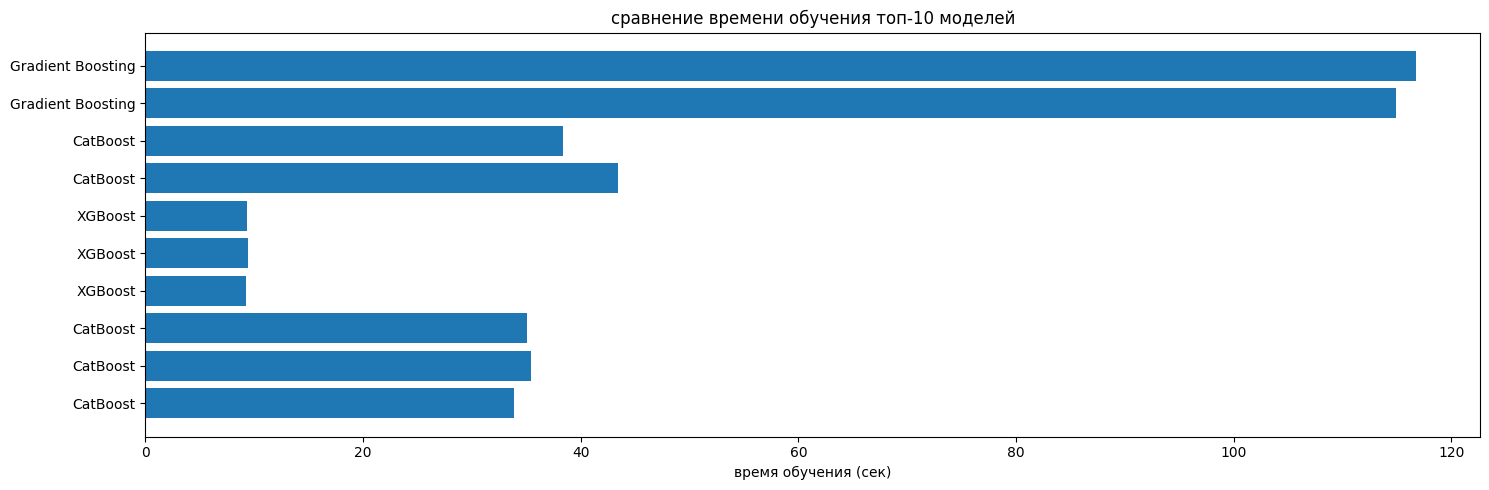

In [41]:
plt.figure(figsize=(15, 5))
top_models = results_df.head(10)
plt.barh(range(len(top_models)), top_models['train_time_sec'])
plt.yticks(range(len(top_models)), top_models['model'])
plt.xlabel('время обучения (сек)')
plt.title('cравнение времени обучения топ-10 моделей')
plt.tight_layout()
plt.show()

подберем наилучшие параметры для `CatBoostClassifier`

In [ ]:
base_model = CatBoostClassifier(random_state=random_state, iterations=100, verbose=0)
param_grid = {
    'depth': [5, 6, 7],
}

print(f'\nparams: {param_grid}')

texts_col = best_result['texts_col']
df_train_clean = df_train.copy().dropna(subset=composed_features + [texts_col]).copy()

train_texts = df_train_clean[texts_col]
train_targets = df_train_clean[target_col]
train_num_features = df_train_clean[composed_features]

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_df=0.9)
X_train_tfidf = vectorizer.fit_transform(train_texts)

train_num_sparse = csr_matrix(train_num_features.values)
X_train_final = hstack([X_train_tfidf, train_num_sparse])

grid_search = GridSearchCV(
    base_model, 
    param_grid, 
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
)

start_time = time.time()
grid_search.fit(X_train_final, train_targets)
grid_time = time.time() - start_time

print(f'best params: {grid_search.best_params_}')
print(f'best macro f1-score: {grid_search.best_score_}')
print(f'diff: {grid_search.best_score_ - best_result["macro_f1"]}')


params: {'depth': [5, 6, 7]}
Fitting 3 folds for each of 3 candidates, totalling 9 fits
best params: {'depth': 7}
best macro f1-score: 0.878158603791856
diff: 0.01629045991187772


# Лучший результат (экперимент проводился в одинаковых условиях с линейными моделями)
- Модель - `CatBoostClassifier `.
- `macro f1-score` - `0.8619` → `0.8782` (после оптимизации).
- использовались `TF-IDF` + числовые признаки + `text_del_stop_words` (тексты с удаленными стоп-словами).

# Выводы 
1. Нелинейные модели показали отличное качество на текущей задаче (кроме `RandomForestClassifier` с базовыми параметрами, это связано с особенностью задачи - высокая размерность текстовых данных).
2. `CatBoostClassifier` показал лучшую производительность среди всех моделей.
3. Время обучения нелинейных моделей сильно отличается и зависит от гиперпараметров.
4. `GridSearchCV` дал улучшение: `+0.02` к базовому результату.
5. Увеличение `depth` очевидно дает прирост к качеству.

Таким образом, была получена эффективная нелинейная модель для классификации токсичных сообщений с `macro f1-score` = 0.8782, что является хорошим результатом для текущей задачи. Тем не менее ранее была получена линейная модель с `macro f1-score` = 0.9063 (см. файл `ML.ipynb`), что показывает, что не всегда стоит сразу выбирать более сложные модели в ожидании автоматически лучших результатов.